# Knowledge Distillation on CIFAR-10

**Knowledge distillation (KD)** is a model-compression technique introduced by Hinton, Vinyals & Dean (2015). The idea:

1. Train a large, accurate **teacher** model.
2. Train a small **student** model that mimics the teacher's *soft predictions* — not just the correct class, but the full probability distribution.

The intuition is that the teacher's probability distribution contains **"dark knowledge"**: the relative similarities between classes ("this picture of a cat is 0.6 cat, 0.3 dog, 0.0001 truck"). Those similarities are a much richer training signal than a one-hot label.

## The distillation loss

We combine two terms:

$$
\mathcal{L} = \alpha \cdot \underbrace{T^2 \cdot \mathrm{KL}\left(\mathrm{softmax}(z_s / T) \; \| \; \mathrm{softmax}(z_t / T)\right)}_{\text{soft loss — mimic the teacher}}
\; + \; (1 - \alpha) \cdot \underbrace{\mathrm{CE}(z_s, y)}_{\text{hard loss — classify correctly}}
$$

- `z_s`, `z_t` are the student and teacher logits.
- **Temperature `T`** softens the distributions: higher T → flatter softmax → more information from "wrong" classes. Typical values: 2–10.
- **α** balances the two losses. α near 1 means "mostly copy the teacher"; α near 0 means "ignore the teacher".
- The factor **T²** on the soft loss compensates for the fact that gradients through `softmax(z/T)` shrink by `1/T²`.

## This notebook

- **Teacher**: ResNet-18 pretrained on ImageNet, fine-tuned on a CIFAR-10 subset.
- **Student**: a small CNN (`TinyCNN`) with no pretraining.
- We compare student accuracy with and track how close the student's predictions get to the teacher's (measured by KL divergence).

> **Note on compute.** We deliberately use small subsets of CIFAR-10 (10% train, 20% test) and few epochs. Real distillation runs train the teacher to convergence first, then distill for many epochs. The goal here is pedagogical.

## 1. Setup

In [15]:
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# Auto-detect device: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: mps


## 2. Data — CIFAR-10 subsets

CIFAR-10 images are natively **32×32**, but ResNet-18 was pretrained on ImageNet at **224×224**. To reuse those pretrained features we upsample CIFAR images to 224×224. Both teacher and student will see the same inputs, which keeps things simple (the student could also use native 32×32, but then we would need two separate data pipelines).

We use random subsets to keep training quick:

- **Train subset** — 10% of CIFAR-10 train (5 000 images).
- **Test subset**  — 20% of CIFAR-10 test  (2 000 images).

In [16]:
data_transform = transforms.Compose([
    transforms.Resize(224),  # upsample to ResNet input size
    transforms.ToTensor(),
])

full_train = datasets.CIFAR10(root="./data/", train=True,  download=True, transform=data_transform)
full_test  = datasets.CIFAR10(root="./data/", train=False, download=True, transform=data_transform)

CIFAR10_CLASSES = full_train.classes
print(f"Classes: {CIFAR10_CLASSES}")

# Random subsets — use a fixed rng for reproducibility
rng = random.Random(SEED)
train_indices = rng.sample(range(len(full_train)), k=int(0.10 * len(full_train)))
test_indices  = rng.sample(range(len(full_test)),  k=int(0.20 * len(full_test)))

train_subset = Subset(full_train, train_indices)
test_subset  = Subset(full_test,  test_indices)

train_loader = DataLoader(train_subset, batch_size=64,  shuffle=True)
test_loader  = DataLoader(test_subset,  batch_size=256, shuffle=False)

print(f"Train: {len(train_subset)}   Test: {len(test_subset)}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 5000   Test: 2000


## 3. Shared helpers — accuracy and timing

In [17]:
@torch.no_grad()
def accuracy(model, loader):
    """Top-1 classification accuracy of `model` over `loader`."""
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total


def count_params(model):
    """Total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 4. Teacher — ResNet-18 fine-tuned on CIFAR-10

We load ImageNet-pretrained ResNet-18 and swap its final layer for a 10-way classifier. One epoch of fine-tuning on our tiny train subset is already enough to get a non-trivial teacher (≈ 70% test accuracy), which is what we need to demonstrate distillation.

Use `weights=ResNet18_Weights.DEFAULT` (the modern replacement for the deprecated `pretrained=True`).

In [ ]:
def build_teacher(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


teacher = build_teacher()
optimizer_t = optim.Adam(teacher.parameters(), lr=1e-3)

TEACHER_EPOCHS = 1
teacher_total_start = time.time()
for epoch in range(TEACHER_EPOCHS):
    epoch_start = time.time()
    teacher.train()
    running_loss = 0.0
    n = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer_t.zero_grad()
        loss = F.cross_entropy(teacher(imgs), labels)
        loss.backward()
        optimizer_t.step()

        running_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

    print(f"Teacher epoch {epoch + 1}/{TEACHER_EPOCHS}   "
          f"loss: {running_loss / n:.4f}   time: {time.time() - epoch_start:.1f}s")

teacher_total_time = time.time() - teacher_total_start
teacher_acc_final = accuracy(teacher, test_loader)
print(f"\nTeacher total training time: {teacher_total_time:.1f}s")
print(f"Teacher test accuracy:       {teacher_acc_final:.4f}")
print(f"Teacher parameter count:     {count_params(teacher):,}")

### 4.1 Save / reload teacher weights

In [18]:
CHECKPOINT_PATH = "./data/resnet18_teacher_state_one_epoch.pth"

# Save
torch.save(teacher.state_dict(), CHECKPOINT_PATH)

# Example of how a student of this notebook would reload the teacher
# without retraining (pretrained ResNet weights shared via Drive):
# https://drive.google.com/drive/folders/1ZbYJft8q1wVr74rCDuIUuBA_oB-QUBvo?usp=drive_link
#
# teacher = build_teacher()
# teacher.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True, map_location=device))
# teacher.eval()

## 5. Student — a compact CNN (`TinyCNN`)

The student has **no pretraining**. Its job is to reach the highest possible accuracy using only:

- the labels of our small training subset, AND
- the soft predictions of the teacher.

### Architecture

Four convolutional blocks with batch normalization, followed by **global average pooling** and a small linear head:

```
Input  (3, 224, 224)
 → [Conv(3→32)   + BN + ReLU] x2 + MaxPool(2)    (32, 112, 112)
 → [Conv(32→64)  + BN + ReLU] x2 + MaxPool(2)    (64,  56,  56)
 → [Conv(64→128) + BN + ReLU] x2 + MaxPool(2)    (128, 28,  28)
 → [Conv(128→256)+ BN + ReLU]    + MaxPool(2)    (256, 14,  14)
 → AdaptiveAvgPool(1)                             (256,  1,   1)
 → Flatten + Dropout(0.3)
 → Linear(256 → 10)
```

> **Why this design?** The original two-block CNN was too shallow to learn from a teacher's soft labels — most of its parameters lived in a single 200K→256 FC layer that did nothing useful for representation learning. Here we add depth (4 blocks), **batch norm** for stable training without pretraining, and replace the giant FC with **global average pooling**. The result has *more capacity in the convolutional features* while being *smaller overall* than the original — exactly what we want for distillation.

In [19]:
class TinyCNN(nn.Module):
    """Compact CNN used as the distillation student.

    Four conv blocks with batch normalization, followed by global average
    pooling and a small linear head. Deeper than a typical "tiny" CNN so it
    has enough capacity to actually learn from the teacher's soft labels,
    but still ~6x smaller than the ResNet-18 teacher.
    """

    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()

        def conv_bn(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            # Block 1: 224 -> 112
            conv_bn(3, 32),
            conv_bn(32, 32),
            nn.MaxPool2d(2, 2),

            # Block 2: 112 -> 56
            conv_bn(32, 64),
            conv_bn(64, 64),
            nn.MaxPool2d(2, 2),

            # Block 3: 56 -> 28
            conv_bn(64, 128),
            conv_bn(128, 128),
            nn.MaxPool2d(2, 2),

            # Block 4: 28 -> 14
            conv_bn(128, 256),
            nn.MaxPool2d(2, 2),
        )

        # Global average pooling + linear head — no giant FC layer.
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


student = TinyCNN().to(device)
print(student)
print(f"\nStudent parameter count: {count_params(student):,}")

TinyCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

## 6. The distillation loss

Recall:

$$
\mathcal{L} = \alpha \cdot T^2 \cdot \mathrm{KL}\left(\mathrm{softmax}(z_s / T) \; \| \; \mathrm{softmax}(z_t / T)\right)
\; + \; (1 - \alpha) \cdot \mathrm{CE}(z_s, y)
$$

A subtle but critical detail: **`F.kl_div` expects the `input` argument to be log-probabilities**, not probabilities. If you pass `softmax` instead of `log_softmax`, the gradients are wrong and distillation silently under-performs. We use `log_softmax` for the student side.

In [20]:
def distillation_loss(student_logits, teacher_logits, labels, T=4.0, alpha=0.7):
    """Combined soft + hard loss for knowledge distillation.

    Parameters
    ----------
    student_logits, teacher_logits : Tensor (B, C)
        Raw pre-softmax outputs.
    labels : Tensor (B,)
        Ground-truth class indices.
    T : float
        Softmax temperature. Higher -> softer distribution.
    alpha : float in [0, 1]
        Weight of the soft (teacher-mimicking) term.

    Returns
    -------
    Tensor (scalar)  — the combined loss.
    """
    # Hard loss: classic cross-entropy against the true label
    hard_loss = F.cross_entropy(student_logits, labels)

    # Soft loss: KL(student_soft || teacher_soft), both at temperature T.
    # Note: F.kl_div expects the *input* argument to be log-probabilities.
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction="batchmean",
    ) * (T * T)  # T^2 factor keeps gradient magnitudes balanced after scaling

    return alpha * soft_loss + (1 - alpha) * hard_loss

## 7. Train the student with distillation

For each training batch we:

1. Run the teacher (frozen, `no_grad`) to get its logits.
2. Run the student (trainable) to get its logits.
3. Combine hard loss (CE against labels) and soft loss (KL against teacher) via `distillation_loss`.
4. Backprop through the **student only**.

We also track, per epoch:
- student test accuracy (target metric),
- teacher test accuracy (should be roughly constant — sanity check),
- mean KL divergence on the test set (how close the student has moved to the teacher),
- per-epoch time and total training time.

In [21]:
@torch.no_grad()
def mean_test_kl(student, teacher, loader, T):
    """Average KL(student || teacher) on `loader` at temperature T."""
    student.eval()
    teacher.eval()
    running = 0.0
    n_batches = 0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        kl = F.kl_div(
            F.log_softmax(student(imgs) / T, dim=1),
            F.softmax(teacher(imgs) / T, dim=1),
            reduction="batchmean",
        )
        running += kl.item()
        n_batches += 1
    return running / n_batches

In [ ]:
STUDENT_EPOCHS = 15
T = 4.0
ALPHA = 0.7

optimizer_s = optim.Adam(student.parameters(), lr=1e-3)

student_acc_list  = []
teacher_acc_list  = []
kl_distance_list  = []
epoch_times       = []

total_start = time.time()
for epoch in range(STUDENT_EPOCHS):
    epoch_start = time.time()

    student.train()
    teacher.eval()  # teacher stays frozen
    running_loss = 0.0
    n = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(imgs)

        student_logits = student(imgs)
        loss = distillation_loss(student_logits, teacher_logits, labels, T=T, alpha=ALPHA)

        optimizer_s.zero_grad()
        loss.backward()
        optimizer_s.step()

        running_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)

    student_acc = accuracy(student, test_loader)
    teacher_acc = accuracy(teacher, test_loader)
    kl_dist     = mean_test_kl(student, teacher, test_loader, T=T)
    epoch_time  = time.time() - epoch_start

    student_acc_list.append(student_acc)
    teacher_acc_list.append(teacher_acc)
    kl_distance_list.append(kl_dist)
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch + 1}/{STUDENT_EPOCHS}   "
          f"train loss: {running_loss / n:.4f}   "
          f"student acc: {student_acc:.3f}   "
          f"KL(s||t): {kl_dist:.4f}   "
          f"time: {epoch_time:.1f}s")

total_time = time.time() - total_start
print(f"\nTotal student training time: {total_time:.1f}s   "
      f"(mean per epoch: {total_time / STUDENT_EPOCHS:.1f}s)")

Epoch 1/15   train loss: 14.7261   student acc: 0.354   KL(s||t): 0.8494   time: 37.3s
Epoch 2/15   train loss: 14.0771   student acc: 0.374   KL(s||t): 0.8340   time: 34.6s


## 8. Evaluation

Two plots:

- **Accuracy vs epoch** — student climbing while the teacher stays ~flat.
- **KL divergence vs epoch** — distance from the student's distribution to the teacher's. A shrinking curve means the student is learning to imitate the teacher, not just classify correctly.

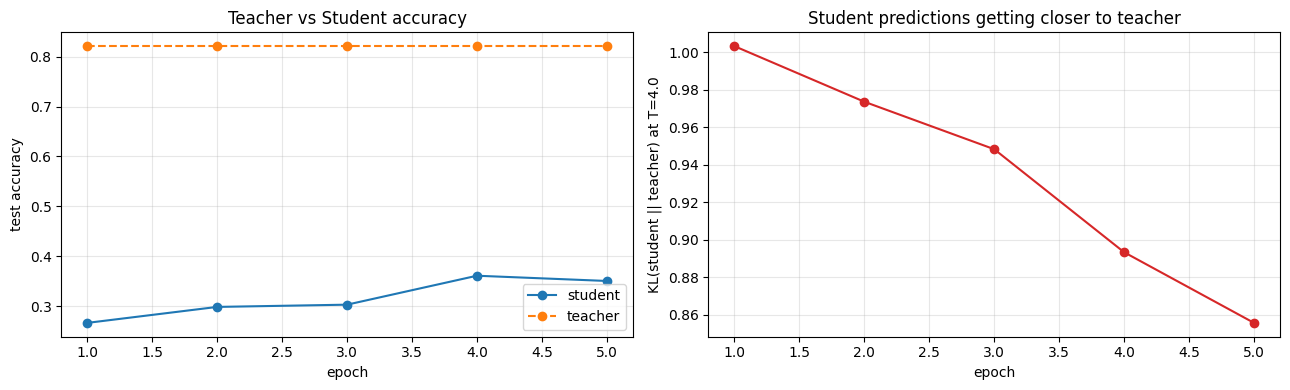

In [ ]:
epochs = np.arange(1, STUDENT_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, student_acc_list, marker="o", label="student")
axes[0].plot(epochs, teacher_acc_list, marker="o", linestyle="--", label="teacher")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Teacher vs Student accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, kl_distance_list, marker="o", color="tab:red")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(f"KL(student || teacher) at T={T}")
axes[1].set_title("Student predictions getting closer to teacher")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.1 Compression summary

In [25]:
teacher_params = count_params(teacher)
student_params = count_params(student)

print(f"Teacher (ResNet-18):     {teacher_params:>12,} params   test acc: {teacher_acc_list[-1]:.3f}")
print(f"Student (TinyCNN):       {student_params:>12,} params   test acc: {student_acc_list[-1]:.3f}")
print(f"Student/Teacher ratio:   {student_params / teacher_params:.2f}x parameters")
print()
print("Note: the student uses global average pooling instead of a large FC layer,")
print("so almost all of its parameters are in the convolutional features — where")
print("they actually contribute to learning useful representations.")

Teacher (ResNet-18):       11,181,642 params   test acc: 0.821
Student (TinyCNN):            585,450 params   test acc: 0.350
Student/Teacher ratio:   0.05x parameters

Note: the student uses global average pooling instead of a large FC layer,
so almost all of its parameters are in the convolutional features — where
they actually contribute to learning useful representations.


## 9. Takeaways and things to try next

- **Distillation transfers "dark knowledge"**: the student trains on the teacher's full probability distribution, which is a richer signal than one-hot labels.
- The **temperature `T`** controls how much information flows from the non-top classes. Too low → behaves like hard-label training; too high → distribution becomes uniform and the signal washes out.
- The **`T²` factor** on the soft loss is not cosmetic — without it, scaling logits by `1/T` shrinks gradients by `1/T²` and the soft loss effectively disappears at high T.
- **Use `log_softmax` on the student side** when calling `F.kl_div` — this is the easiest bug to introduce and the hardest to notice.

### Exercises

1. **Temperature sweep.** Try `T ∈ {1, 2, 4, 8, 16}` and plot final student accuracy. Where is the sweet spot on your data?
2. **α sweep.** Fix `T=4` and try `alpha ∈ {0.0, 0.25, 0.5, 0.75, 1.0}`. What does α=0 mean? What about α=1?
3. **No-distillation baseline.** Train the same `TinyCNN` with only cross-entropy (`alpha=0` in `distillation_loss`). How much accuracy does distillation actually add?
4. **Native 32×32 student.** Build a version of `TinyCNN` that takes 32×32 CIFAR images directly, shrink the FC layer accordingly, and distill from the 224×224 teacher. This requires two data pipelines but is much closer to real deployment.
5. **Train the teacher longer** (5–10 epochs). How does a stronger teacher change the final student accuracy?